Unikalne wartości w kolumnie 'Label':
[0 1]
Label
0    413933
1    288785
Name: count, dtype: int64
Epoch 1/10
9314/9314 ━━━━━━━━━━━━━━━━━━━━ 4s 411us/step - loss: 0.5559 - val_loss: 0.0722
Epoch 2/10
9314/9314 ━━━━━━━━━━━━━━━━━━━━ 4s 392us/step - loss: 0.1933 - val_loss: 0.0478
Epoch 3/10
9314/9314 ━━━━━━━━━━━━━━━━━━━━ 4s 390us/step - loss: 0.3487 - val_loss: 0.0298
Epoch 4/10
9314/9314 ━━━━━━━━━━━━━━━━━━━━ 4s 390us/step - loss: 0.3351 - val_loss: 0.0483
Epoch 5/10
9314/9314 ━━━━━━━━━━━━━━━━━━━━ 4s 388us/step - loss: 0.1404 - val_loss: 0.0316
Epoch 6/10
9314/9314 ━━━━━━━━━━━━━━━━━━━━ 4s 392us/step - loss: 0.1318 - val_loss: 0.0180
Epoch 7/10
9314/9314 ━━━━━━━━━━━━━━━━━━━━ 4s 387us/step - loss: 0.1767 - val_loss: 0.0643
Epoch 8/10
9314/9314 ━━━━━━━━━━━━━━━━━━━━ 4s 388us/step - loss: 0.4452 - val_loss: 0.0158
Epoch 9/10
9314/9314 ━━━━━━━━━━━━━━━━━━━━ 4s 389us/step - loss: 0.2453 - val_loss: 0.0462
Epoch 10/10
9314/9314 ━━━━━━━━━━━━━━━━━━━━ 4s 386us/step - loss: 0.2479 - val_loss: 0.0198

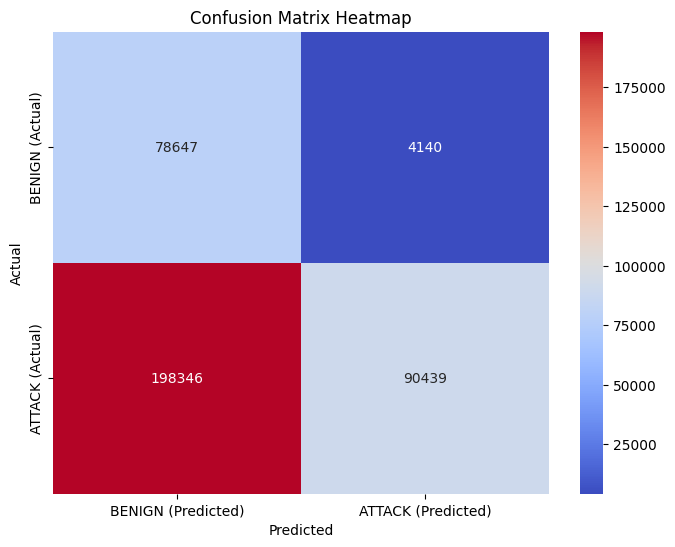

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense

# Wczytaj dane
day = 'Friday'
processed_filepath = './datasets/processed/'
data = pd.read_csv(processed_filepath + f'{day}.csv')
df = data.copy()

# Przygotuj dane
X = df.drop('Label', axis=1).values
y = df['Label'].values

print("Unikalne wartości w kolumnie 'Label':")
unique_labels = df['Label'].unique()
label_counts = df['Label'].value_counts()
print(unique_labels)
print(label_counts)

# Normalizacja
scaler = StandardScaler()
X_normalized = scaler.fit_transform(X)

# Podział na train/test (tylko BENIGN do trenowania autoenkodera)
X_benign = X_normalized[y == 0]
y_benign = y[y == 0]
X_attack = X_normalized[y != 0]
y_attack = y[y != 0]

# Podział tylko dla BENIGN
X_benign_train, X_benign_test, y_benign_train, y_benign_test = train_test_split(
    X_benign, y_benign, test_size=0.2, random_state=42
)

# Zbiór testowy: BENIGN (test) + ATTACK (wszystkie)
X_test = np.vstack([X_benign_test, X_attack])
y_test = np.concatenate([y_benign_test, y_attack])

# Budowa autoenkodera
input_dim = X_benign_train.shape[1]
input_layer = Input(shape=(input_dim,))
encoded = Dense(64, activation='relu')(input_layer)
encoded = Dense(32, activation='relu')(encoded)
decoded = Dense(64, activation='relu')(encoded)
decoded = Dense(input_dim, activation='linear')(decoded)

autoencoder = Model(inputs=input_layer, outputs=decoded)
autoencoder.compile(optimizer='adam', loss='mse')

# Trening tylko na benign
history = autoencoder.fit(
    X_benign_train, X_benign_train,
    epochs=5, batch_size=32, validation_split=0.1, verbose=1
)

# Rekonstrukcja i błąd rekonstrukcji
X_test_pred = autoencoder.predict(X_test)
mse = np.mean(np.square(X_test - X_test_pred), axis=1)

# Ustal próg (np. 95 percentyl błędu na danych BENIGN z testu)
threshold = np.percentile(mse[:len(y_benign_test)], 95)

# Klasyfikacja: 1 = atak (anomalia), 0 = benign
y_pred = (mse > threshold).astype(int)
y_true = (y_test != 0).astype(int)  # 1 = atak, 0 = benign

# Ewaluacja
cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:")
print(cm)
print(classification_report(y_true, y_pred, target_names=['BENIGN', 'ATTACK']))

# Wizualizacja macierzy konfuzji
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='coolwarm', 
            xticklabels=['BENIGN (Predicted)', 'ATTACK (Predicted)'], 
            yticklabels=['BENIGN (Actual)', 'ATTACK (Actual)'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix Heatmap')
plt.show()